In [ ]:
from google.colab import files
uploaded = files.upload()

Saving personality_dataset (1).csv to personality_dataset (1).csv


   Time_spent_Alone Stage_fear  Social_event_attendance  Going_outside  \
0               4.0         No                      4.0            6.0   
1               9.0        Yes                      0.0            0.0   
2               9.0        Yes                      1.0            2.0   
3               0.0         No                      6.0            7.0   
4               3.0         No                      9.0            4.0   

  Drained_after_socializing  Friends_circle_size  Post_frequency Personality  
0                        No                 13.0             5.0   Extrovert  
1                       Yes                  0.0             3.0   Introvert  
2                       Yes                  5.0             2.0   Introvert  
3                        No                 14.0             8.0   Extrovert  
4                        No                  8.0             5.0   Extrovert  


<ipython-input-16-196ff70d329a>:19: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  a = a.fillna(method='ffill')


Time_spent_Alone: 0.1427
Stage_fear: 0.3093
Social_event_attendance: 0.1597
Going_outside: 0.0445
Drained_after_socializing: 0.3438


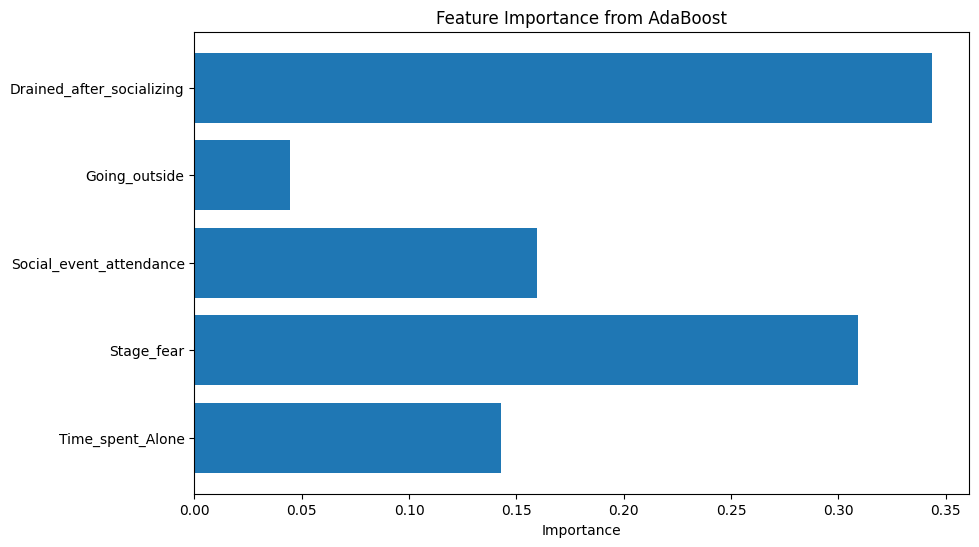

[[427  36]
 [ 28 379]]
0.9264367816091954
0.9132530120481928
0.9312039312039312
0.9221411192214112
[[953  75]
 [ 52 950]]
0.9374384236453202
0.926829268292683
0.9481037924151696
0.9373458312777504


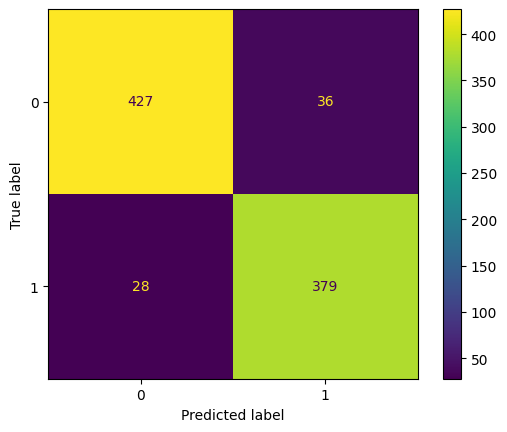

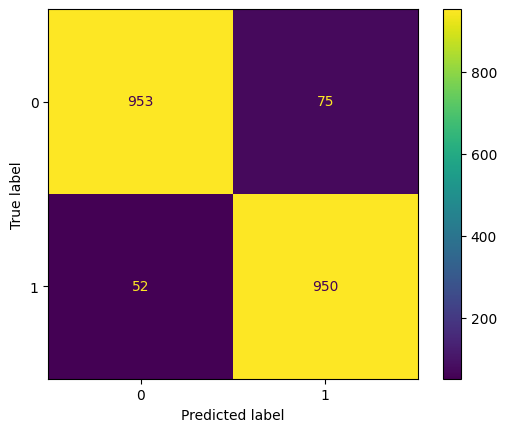

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier,RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score,ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder


a = pd.read_csv("personality_dataset (1).csv")
print(a.head())




a = a.fillna(a.median(numeric_only = True))
a = a.fillna(method='ffill')

X = a.drop(["Personality","Friends_circle_size","Post_frequency"],axis=1)
y = a["Personality"]



le = LabelEncoder()
for i in X.columns:
    if X[i].dtype == 'object':
        X[i] = le.fit_transform(X[i])
if y.dtype == 'object':
    y = le.fit_transform(y)


X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)


model = DecisionTreeClassifier(

      max_depth=1,
      random_state= 42
)




param_grid = {
    "n_estimators": [20, 50, 70],
    "learning_rate": [0.1, 0.5, 1.0,2.0],
     "estimator": [model]
}

grid = GridSearchCV(
    estimator=AdaBoostClassifier(random_state=42),
    param_grid=param_grid,
    #scoring='f1',
    cv=5,
    n_jobs=-1
)


"""model1 = AdaBoostClassifier(

    estimator=model,
    learning_rate=1.0,
    n_estimators=20,
    random_state= 42



)"""

grid.fit(X_train,y_train)






best_model = grid.best_estimator_


importances = best_model.feature_importances_
feature_names = X.columns


for name, importance in zip(feature_names, importances):
    print(f"{name}: {importance:.4f}")

plt.figure(figsize=(10, 6))
plt.barh(feature_names, importances)
plt.xlabel("Importance")
plt.title("Feature Importance from AdaBoost")
plt.show()






#











y_pred = grid.predict(X_test)

cm = confusion_matrix(y_test,y_pred)
print(cm)
acc = accuracy_score(y_test,y_pred)
print(acc)
prec = precision_score(y_test,y_pred)
print(prec)
rec = recall_score(y_test,y_pred)
print(rec)
f1 = f1_score(y_test,y_pred)
print(f1)





y_train_preed = grid.predict(X_train)

cm1 = confusion_matrix(y_train,y_train_preed)
print(cm1)
acc1 = accuracy_score(y_train,y_train_preed)
print(acc1)
prec1 = precision_score(y_train,y_train_preed)
print(prec1)
rec1 = recall_score(y_train,y_train_preed)
print(rec1)
f1 = f1_score(y_train,y_train_preed)
print(f1)





disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=grid.classes_)
disp.plot()
plt.show()



disp = ConfusionMatrixDisplay(confusion_matrix=cm1,display_labels=grid.classes_)
disp.plot()
plt.show()




